# Lab 4: Learning
You will find the complete lab manual in this file. Some exercises require written answers, while others require coding.

This lab is built around two examples: a logistic classifier applied to the cell images from Lab 1, and convolutional neural networks applied to MNIST using PyTorch. In the first part, you implement and train a logistic classifier for the cell image task. You investigate how the result depends on the initialization, how long the model needs to be trained, and what the learned classifier looks like after training. In the second part, you implement a few simple convolutional neural networks for handwritten digit classification on MNIST. You will test how the model can be improved by changing the network structure or the training strategy. The goal of the lab is to make the learning process concrete: how parameters are initialized, optimized, evaluated, and interpreted.

**Observe:** You should not install any other packages than the ones given in the pre-amble. You are expected to yourself look up documentation of given functions from libraries, e.g. OpenCV and PyTorch. You are allowed to use any methods in the packages that you see fit to solve the problems. It is highly encouraged to look at the documentation and search for usage instructions online, before asking for help.

**Observe:** Write your answers to questions directly in the cells denoted with **Your answer**.

## Submission Requirements:
Your final lab submission should include:
1. Your executed **notebook file** (`.ipynb`) including an AI usage statement.
2. A **HTML printout** of the executed notebook with all outputs visible. 

## AI Usage Statement
Please detail your use of AI in this cell.

Claude (claude-sonnet-4-6 via Claude Code) was used as an assistant during the completion of this lab. The AI was not used to directly write or generate implementation code, but was consulted for conceptual explanations and debugging guidance throughout the assignment.

Specifically, the AI was used to:

- Explain the binary cross-entropy loss and clarify which terms are relevant for the partial gradient computation
- Explain what a logit is and clarify numerically stable sigmoid computation, recommending `scipy.special.expit`
- Clarify NumPy array operations including `np.reshape`, `np.delete`, `np.concatenate`, `np.meshgrid`, and boolean mask selection
- Explain how to generate pairwise combinations of hyperparameter values using `np.meshgrid` and `np.stack`
- Explain coarse-to-fine hyperparameter grid search using `np.logspace` for coarse and `np.linspace` for finer stages
- Explain data augmentation via `scipy.ndimage.rotate` and how to integrate augmented samples into training
- Explain PyTorch tensor shape convention (batch, channels, H, W) and `nn.Conv2d`, `nn.MaxPool2d`, `nn.Linear` layer behaviour
- Clarify how output spatial dimensions are computed through convolutional and pooling layers
- Clarify that `nn.CrossEntropyLoss` applies softmax internally and that softmax is not needed at inference when taking the argmax
- Explain how MACs are computed for a convolutional layer and what a multiply-accumulate operation is
- Explain how input channels map to output pixels in a convolutional layer
- Explain the precision and recall formulas and how they extend to multi-class classification using a one-vs-rest approach
- Debug several implementation errors related to incorrect tensor shapes, wrong argument types, and incorrect use of NumPy functions on PyTorch tensors
- Clarify Matplotlib subplot creation and correct usage of `ax.set_title`

All implementations were written by me, with the AI serving as an explanatory resource and assistant during debugging.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob

import scipy.io
import scipy.ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import torchvision
from torch.utils.data import DataLoader, random_split

import torch.optim as optim
from typing import Tuple, Dict
from tqdm.auto import tqdm

## Task 1: Learning a Linear Classifier

In this part, we will return to the blood cell detection task of the first assignment, only this time we will try to _learn_ a linear classifier. Note that the classifier could also be viewed as a minimal neural network consisting of three parts: a scalar product node (or fully-connected node), a constant (or bias) term and a logistic sigmoid function. To find good parameters we will try to minimize the negative log-likelihood over a small training set.

The output from our classifier is a probability $p$ for the input patch $I$ being centered at a cell centre. The sigmoid function will make sure that $0\leq p \leq 1$. To be more precise the output is 
\begin{equation}p = \frac{e^\xi}{1+e^\xi} \quad \text{where} \quad \xi=I\cdot w + w_0\end{equation}
parametrized by weights $\boldsymbol w = [w, w_0]$. Instead of manually finding appropriate values for $\boldsymbol w$, we will try to learn good values for all the parameters. This requires training examples, that you find in `fg_patches.npy` and `bg_patches.npy`.

### Task 1.1
Load the data

In [97]:
fg_patches = np.load("data/fg_patches.npy")
bg_patches = np.load("data/bg_patches.npy")

It loads two numpy arrays, `fg_patches` and `bg_patches`, corresponding to positive (centered blood cells) and negative examples respectively.

### Task 1.2


Create two new variables, examples and labels. The variable `examples` should be an array containing all the patches (both positives and negatives) and `labels` should be an array with the same number of elements such that `labels[i] = 1` if `examples[i]` is a positive example, and `labels[i] = 0` otherwise.

In [98]:
def labels_and_examples_from_data(fg_patches: np.ndarray, bg_patches: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create the labels and examples for the training data, where the foreground patches are labeled as 1 and the background patches are labeled as 0.
     
    Args:
        fg_patches (np.ndarray): The foreground patches.
        bg_patches (np.ndarray): The background patches.
         
    Returns:
        Tuple[np.ndarray, np.ndarray]: The examples and labels for the training data.
    """
    labels = np.hstack([np.ones(fg_patches.shape[0]), np.zeros(bg_patches.shape[0])])
    examples = np.vstack([fg_patches, bg_patches])

    return (examples, labels)

In [99]:
examples, labels = labels_and_examples_from_data(fg_patches, bg_patches)

### Task 1.3
Split the data into training, (`examples_train`, `labels_train`), and validation, (`examples_val`, `labels_val`). The two should have a similar structure to `examples` and `labels`. The splitting of the data into the two sets should be done in a random manner, for example using `np.random.permutation` to shuffle the indices. Write what percentage of data you use for training and validation respectively.

**Percentage of data used for training: 80%**

**Percentage of data used for validation: 20%**

In [100]:
def split_data(examples: np.ndarray, labels: np.ndarray, train_ratio: float = 0.8) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split the data into random training and test sets given a specified training set ratio.
     
    Args:
        examples (np.ndarray): The examples for the training data.
        labels (np.ndarray): The labels for the training data.
        train_ratio (float): The ratio of the training data to the total data.
         
    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: The training examples, training labels, validation examples, and validation labels.
    """
    r_i = np.random.choice(labels.size, int(labels.size * train_ratio), replace=False)
    return (examples[r_i], labels[r_i], np.delete(examples, r_i, axis=0), np.delete(labels, r_i, axis=0))
    

In [101]:
examples_train, labels_train, examples_val, labels_val = split_data(examples, labels)
print(f"Training examples: {examples_train.shape}, Training labels: {len(labels_train)}, Validation examples: {examples_val.shape}, Validation labels: {len(labels_val)}")

Training examples: (320, 35, 35), Training labels: 320, Validation examples: (80, 35, 35), Validation labels: 80


## Task 2: Training the Classifier
We will try to find parameters that minimize the negative log-likelihood on the training data. More precisely,
\begin{equation}
L(\boldsymbol w) = \sum_{i\in S_+}-\ln(p_i)+ \sum_{i\in S_-}-\ln(1-p_i) = \sum_i L_i (\boldsymbol w)
\end{equation}

where $p_i$ refers to the classifier output for the _i_ th training example. The minimization objective is commonly also called a _loss function_. As in the lectures we will refer to the terms here as the _partial loss_ $L_i$.

In order to minimize the loss, we will employ _stochastic gradient descent_, which requires us to first compute the gradient of the negative log-likelihood with respect to each parameter, i.e. $\partial/\partial w$, $\partial/\partial w_0$. The parameters are then updated from their previous value at a _learning rate_ $\eta$:

$$
\begin{align}
w \leftarrow& w - \eta \frac{\partial}{\partial w} L_i\\
w_0 \leftarrow& w - \eta \frac{\partial}{\partial w_0} L_i
\end{align}
$$

or more succinctly,

$$
{\boldsymbol w} \leftarrow {\boldsymbol w} - \eta \nabla L_i.
$$

Before doing the next exercise, you need to work out how to compute the gradient of the partial loss $L_i$ with respect to the parameters ${\boldsymbol w} = [w, w_0]$.

### Task 2.1
Make a function `partial_gradient` that computes the derivatives of the partial loss $L_i$ with respect to each of the classifier parameters.

In [102]:
def partial_gradient(w: np.ndarray, w0: float, examples_train: np.ndarray, labels_train: int) -> Tuple[np.ndarray, float]:
    """
    Computes the derivatives of the partial loss Li with respect to each of the classifier parameters.

    Args:
        w: weight vector (same shape as examples_train)
        w0: bias term (scalar)
        examples_train: input image / example (same shape as w)
        labels_train: 0 or 1 (negative or positive example)

    Returns:
        wgrad: gradient with respect to w
        w0grad: gradient with respect to w0
    """
    logit = (w * examples_train).sum() + w0
    activation = 1 / (1 + np.exp(-logit))
    wgrad = examples_train * (activation - labels_train)
    w0grad = (activation - labels_train)
    return wgrad, w0grad
    
    

### Task 2.2
In _stochastic gradient descent_, a training example, $i$, is chosen at random at each iteration. For this example, the gradient of the partial loss, $L_i$, is computed and the parameters are updated according to this gradient. The most common way to introduce the randomness is to randomly shuffle the data order before each pass over the entire data. One pass over the data is called an epoch.



Make a function `process_epoch` that performs one epoch of stochastic gradient descent.

In [103]:
def process_epoch(w: np.ndarray, w0: float, lrate: float, examples_train: np.ndarray, labels_train: np.ndarray, shuffle: bool = True) -> Tuple[np.ndarray, float]:
    """
    Performs one epoch of stochastic gradient descent, by means of shuffling the data 
    and then iterating through the training examples one by one, 
    computing the partial gradients and updating the parameters.

    Args:
        w: weight array (same shape as examples_train)
        w0: bias term (scalar)
        lrate: learning rate (scalar)
        examples_train: array of training examples (e.g., shape (N, 35, 35))
        labels_train: array of labels (shape (N,))
        shuffle: whether to shuffle the data before processing

    Returns:
        w: updated weight array
        w0: updated bias term
    """

    n = examples_train.shape[0]
    indices = np.arange(n)
    if shuffle:
        indices = np.random.permutation(n)

    for i in indices:
        example = examples_train[i, :, :]
        label = labels_train[i]

        wgrad, w0grad = partial_gradient(w, w0, example, label)
        w = w - lrate * wgrad
        w0 = w0 - lrate * w0grad

    return w, w0
        
    

### Task 2.3
We will now try to train the classifier. The parameters will require an initialization, which in our case will be a standard Gaussian initialization for $w$, and 0 for $w_0$, i.e. `w = np.random.randn(35,35); w0 = 0`. Visualize the resulting weight $w$ using `plt.imshow` after each epoch.

In [104]:
def train(
        w: np.ndarray, 
        w0: float, 
        lrate: float, 
        examples_train: np.ndarray, 
        labels_train: np.ndarray, 
        num_epochs: int = 10, 
        plot_frequency: int = 1,
        shuffle: bool = True
        ) -> Tuple[np.ndarray, float]:
    """
    Trains the logistic regression model using stochastic gradient descent for a specified number of epochs.

    Args:
        w: initial weight array (same shape as examples_train)
        w0: initial bias term (scalar)
        lrate: learning rate (scalar)
        examples_train: array of training examples (e.g., shape (N, 35, 35))
        labels_train: array of training labels (shape (N,))
        examples_test: array of test examples (shape (M, 35, 35))
        labels_test: array of test labels (shape (M,))
        num_epochs: number of epochs to train
        plot_frequency: how often to plot the training progress (every n epochs), set to 0 to disable plotting
        shuffle: whether to shuffle the data before each epoch

    Returns:
        w: final weight array after training
        w0: final bias term after training
    """
    do_plot = plot_frequency > 0
    for e in range(num_epochs):
        w, w0 = process_epoch(w, w0, lrate, examples_train, labels_train, shuffle)
        if do_plot and ((e % plot_frequency) == 0):
            plt.imshow(w, cmap='gray')
            plt.title(f"Weights from epoch ({e+1})")
            plt.show()

    return w, w0

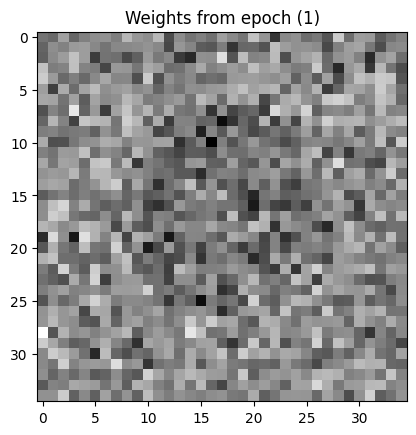

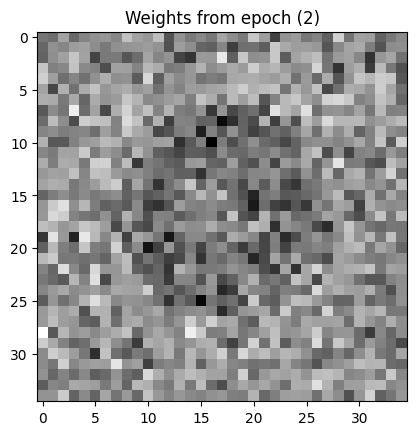

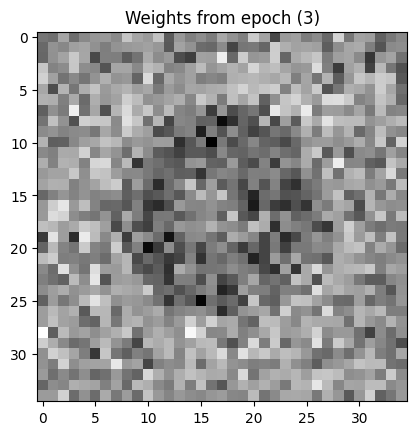

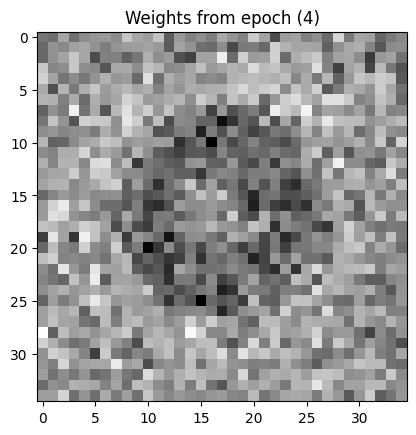

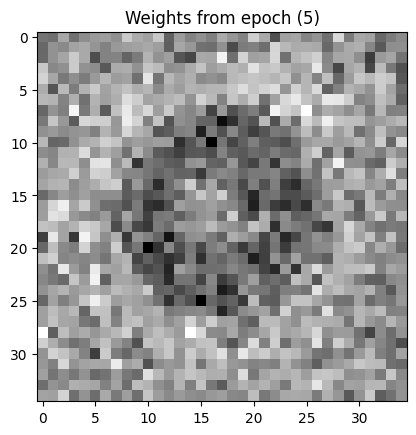

In [105]:
w, w0 = train(w=np.random.randn(35, 35), w0=0.0, lrate=0.11, examples_train=examples_train, labels_train=labels_train, num_epochs=5, plot_frequency=1)

Try using different initialization scales `s=[10,1,0.1,0.01]` such that `w= s * np.random.randn(35,35)` and plot `w` after 5 epochs for each value of `s`. Why do the scale of the initialization impact the result? Compute the partial gradient for $w$ manually for $w=0.01$ and $w=10$ and discuss what may be happening.


--------------------
Processing scale (0.01)


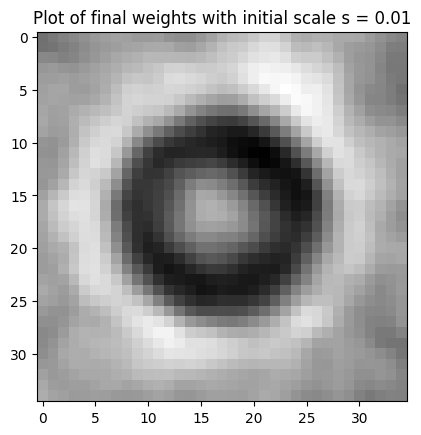


--------------------
Processing scale (0.1)


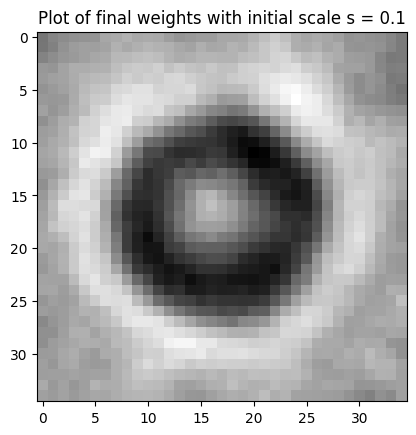


--------------------
Processing scale (1)


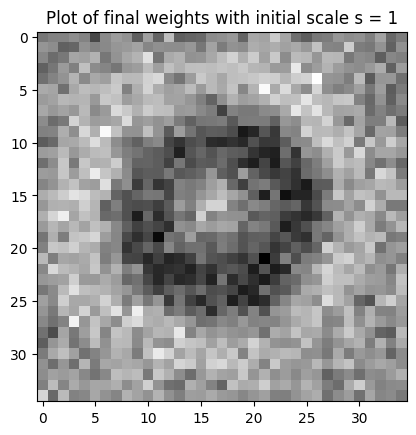


--------------------
Processing scale (10)


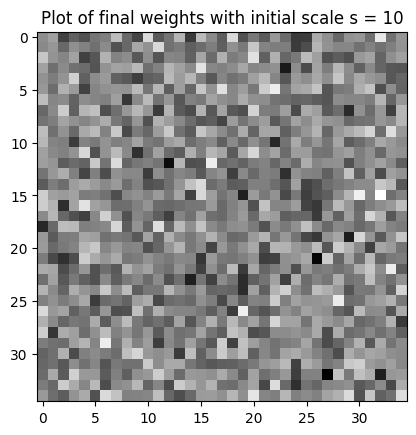



Gradient with w = 0.01
logit = (0.01), activation = (0.5024999791668749), wgrad = (-0.49750002083312506)
Gradient with w = 10
logit = (10), activation = (0.9999546021312976), wgrad = (-4.5397868702390376e-05)


In [106]:
scales = [0.01, 0.1, 1, 10] # may also be written np.logspace(-2, 1, num=4) to generate logarithmically spaced values
num_epochs = 5
learning_rate = 0.2
plot_frequency = 5

for s in scales:
    print("\n" + "-" * 20)
    print(f"Processing scale ({s})")
    w, w0 = train((s * np.random.randn(35, 35)), 0.0, learning_rate, examples_train, labels_train, num_epochs, 0)
    plt.imshow(w, cmap='gray')
    plt.title(f"Plot of final weights with initial scale s = {s}")
    plt.show()

print("\n")
print("Gradient with w = 0.01")
logit = 0.01 * 1
activation = (np.e ** logit) / (1 + np.e ** logit)
wgrad = (activation - 1)
print(f"logit = ({logit}), activation = ({activation}), wgrad = ({wgrad})")

print("Gradient with w = 10")
logit = 10 * 1
activation = (np.e ** logit) / (1 + np.e ** logit)
wgrad = (activation - 1)
print(f"logit = ({logit}), activation = ({activation}), wgrad = ({wgrad})")
    

**Your answer:** 

The scale of the initialization impacts the result since the scale of the initial weights determines the magnitude of the gradient in the first few steps. This result follows from the shape of the sigmoid function where values larger than 2 or lower than -2 become squashed to similar activations, approaching 1 and 0 respectively. By setting a large scale like $s = 10$ we make all weights surpass the point of the sigmoid function where the activations vary, making all input images squash to similar activations. This results in similar gradients for all images as well as very small gradient magnitudes as observed by the manual calculation. Effectively, by having too large of a scale we negate the learning process entirely and the weights barely move. We can clearly observe the slow (non-existant) learning of this effect in the above plot with $s=10$, where the plot resembles random gaussian noise even after 5 epochs. 

However, by setting a lower scale like $s = 0.01$ we put all weights near the center of the sigmoid function where $x = 0$ results in an activation of 0.5. In this way we introduce logits approximately centered around $x = 0$ with as random gaussian noise which produces activations around 0.5 resulting in the largest possible gradient magnitudes for the sigmoid function. As result we obtain strong gradients and therefore meaningful updates to the weights in the early stages of the training. This leads to better convergence which is observable in the first two plots shown above. In those cases the weights have meaninfully converged to a cell like form as compared to the other plots with higher scales.

### Task 2.4
Make a function `classify` that applies the classifier to the example data. After that, use it on `examples_train` and `examples_val` and check how much accuracy it gets for each by comparing the predicted labels with `labels_train` and `labels_val` respectively. Write on your report the highest accuracy you were able to achieve in the training and validation data. 

Hint: train the classifier for longer than 5 epochs to make sure that it converges, tweak your learning rate and initialization scale.

In [107]:
def classify(examples_val: np.ndarray, w: np.ndarray, w0: float) -> np.ndarray:
    """
    Applies a classifier to the example data.
    
    Args:
        examples_val: array of examples to classify (shape (N, 35, 35))
        w: weight array (same shape as each example in examples_val)
        w0: bias term (scalar)

    Returns:
        predicted_labels: Array of predicted labels (0 or 1) for each example
    """

    logits = (w * examples_val).sum(axis=(1, 2))
    activations = 1 / (1 + np.exp(-logits))
    predicted_labels = np.round(activations)
    return predicted_labels

def accuracy(labels: np.ndarray, predicted_labels: np.ndarray) -> float:
    """
    Computes the accuracy of the classifier.
    
    Args:
        labels: true labels (shape (N,))
        predicted_labels: predicted labels (shape (N,))
    
    Returns:
        accuracy: Accuracy of the classifier as a percentage
    """
    return np.mean(predicted_labels == labels)*100


In [108]:
def run_grid_search(learning_rates, scales, examples, labels, examples_val, labels_val, num_epochs):
    A, B = np.meshgrid(learning_rates, scales)
    pairs = np.stack([A.ravel(), B.ravel()], axis=1)
    
    best_accuracy = -1
    best_w = np.inf
    best_w0 = np.inf
    best_lr = np.inf
    best_scale = np.inf
    
    for (lr, scale) in tqdm(pairs, desc="Grid search"):
        w, w0 = train((scale * np.random.randn(35, 35)), 0.0, lr, examples, labels, num_epochs, 0)
        acc = accuracy(labels_val, classify(examples_val, w, w0))
        if acc > best_accuracy:
            best_w = w
            best_w0 = w0
            best_lr = lr
            best_scale = scale
            best_accuracy = acc

    train_acc = accuracy(labels, classify(examples, best_w, best_w0))
    plt.imshow(best_w, cmap='gray')
    plt.title(f"Plot of best weights with lr=({best_lr:.6f}), scale=({best_scale:.6f}), val_acc=({best_accuracy:.6f}), train_acc=({train_acc:.6f})")
    plt.show()

    return best_accuracy, best_w, best_w0, best_lr, best_scale

--------------------
Processing coarse


Grid search: 100%|████████████████████████████| 900/900 [01:16<00:00, 11.75it/s]


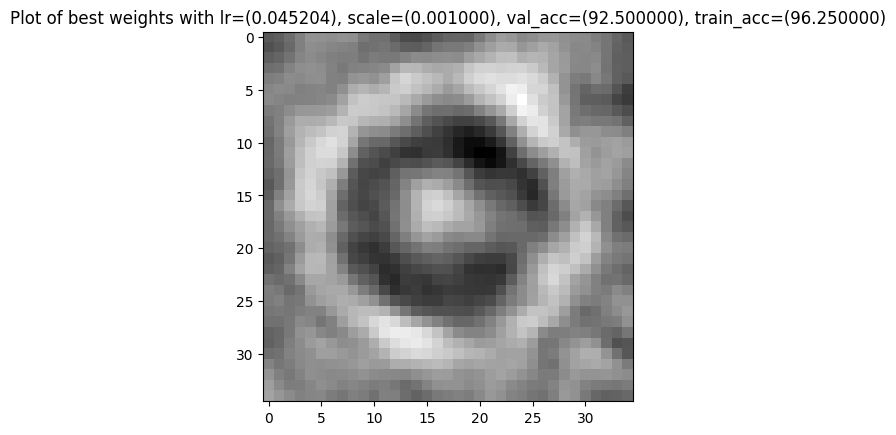


--------------------
Processing medium


Grid search: 100%|████████████████████████████| 400/400 [00:32<00:00, 12.44it/s]


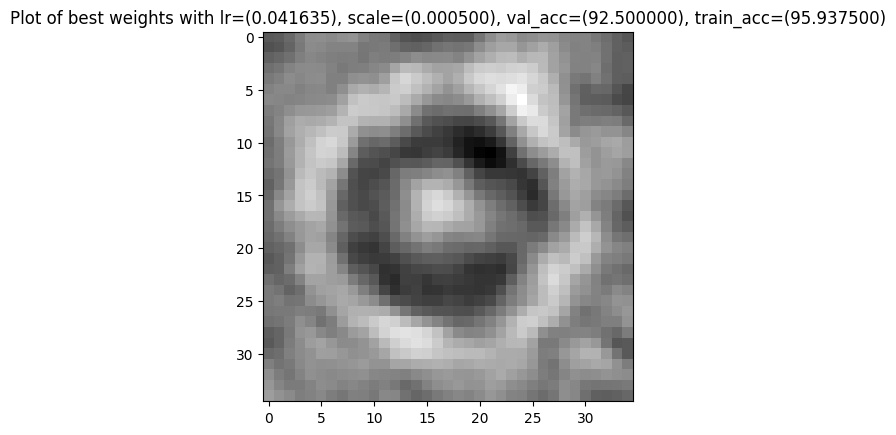


--------------------
Processing fine


Grid search: 100%|████████████████████████████| 100/100 [00:08<00:00, 12.11it/s]


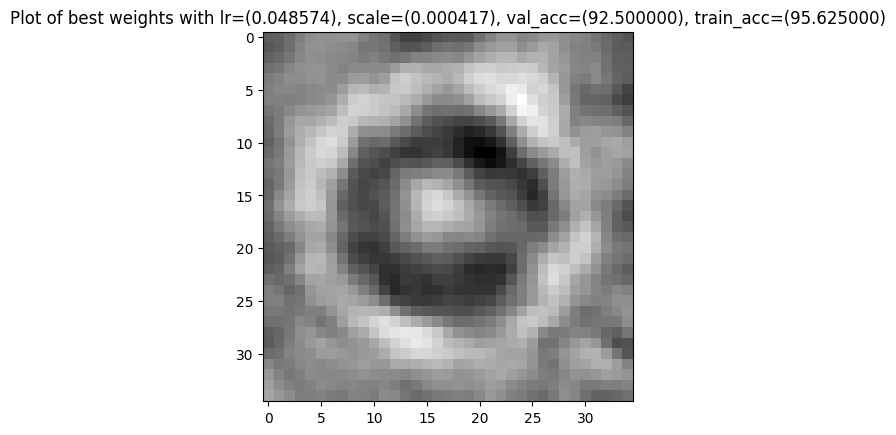

In [113]:
num_epochs = 50
    
# Coarse
print("-" * 20)
print("Processing coarse")
learning_rates = np.logspace(-3, -1, num=30)
scales = np.logspace(-3, -1, num=30)
best_accuracy, best_w, best_w0, best_lr, best_scale = run_grid_search(learning_rates, scales, examples_train, labels_train, examples_val, labels_val, num_epochs)

# Medium
print("\n" + "-" * 20)
print("Processing medium")
learning_rates = np.linspace(best_lr * 0.5, best_lr * 1.5, num=20)
scales = np.linspace(best_scale * 0.5, best_scale * 1.5, num=20)
best_accuracy, best_w, best_w0, best_lr, best_scale = run_grid_search(learning_rates, scales, examples_train, labels_train, examples_val, labels_val, num_epochs)

# Fine
print("\n" + "-" * 20)
print("Processing fine")
learning_rates = np.linspace(best_lr * 0.5, best_lr * 1.5, 0.1, num=10)
scales = np.linspace(best_scale * 0.5, best_scale * 1.5, num=10)
best_accuracy, best_w, best_w0, best_lr, best_scale = run_grid_search(learning_rates, scales, examples_train, labels_train, examples_val, labels_val, num_epochs)

w = best_w
w0 = best_w0

When you have defined the function run the following code.

In [114]:
acc = accuracy(labels_val, classify(examples_val, w, w0))
train_acc = accuracy(labels_train, classify(examples_train, w, w0))
print(f"Test Accuracy: {acc}, Train accuracy: {train_acc}")

Test Accuracy: 92.5, Train accuracy: 95.625


### Task 2.5
The data for training this classifier consists of only 400 examples (less if you consider that you have split it into training and validation). To achieve higher accuracy it might be useful to perform some data augmentation before the training. In this exercise you will increase the number of elements in the training examples by $M$ times. Make a function `augment_data` that takes each sample of the original training data and applies M random rotations (you can use function `scipy.ndimage.rotate`), resulting in $M$ new examples. Store these new examples in `examples_train_aug` and their corresponding labels in `labels_train_aug`.

In [115]:
def augment_data(examples_train: np.ndarray, labels_train: np.ndarray, M: int):
    """
    Data augmentation: Takes each sample of the original training data and 
    applies M random rotations, which result in M new examples.
    
    Args:
        examples_train: Array of training examples (shape (N, 35, 35))
        labels_train: Array of labels corresponding to the examples
        M: Number of random rotations to apply to each training example

    Returns:
        examples_train_aug: Augmented examples after rotations
        labels_train_aug: Corresponding labels for augmented examples
    """
    examples_train_aug = np.zeros((labels_train.size * M, examples_train.shape[1], examples_train.shape[2]))
    labels_train_aug = np.zeros(labels_train.size * M)
    
    for i in range(labels_train.size):
        example = examples_train[i, :, :]
        label = labels_train[i]
        labels_aug = np.full(M, label)
        examples_aug = np.zeros((M, example.shape[0], example.shape[1]))

        rotation_angles = np.random.uniform(-180, 180, M)
        for j in range(M):
            examples_aug[j, :, :] = scipy.ndimage.rotate(example, rotation_angles[j], reshape=False)

        examples_train_aug[M*i:M*i+M] = examples_aug
        labels_train_aug[M*i:M*i+M] = labels_aug

    return examples_train_aug, labels_train_aug
        

Train the classifier with this augmented data and write on your report the new values for accuracy on the training and validation examples.

In [116]:
M = 100
[examples_train_aug,labels_train_aug] = augment_data(examples_train,labels_train,M)


--------------------
Processing grid search from subset of augmented values


Grid search: 100%|████████████████████████████| 400/400 [02:49<00:00,  2.37it/s]


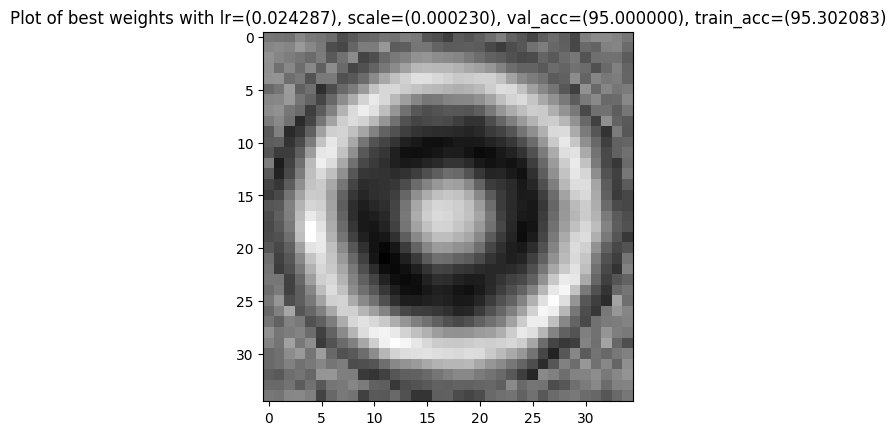

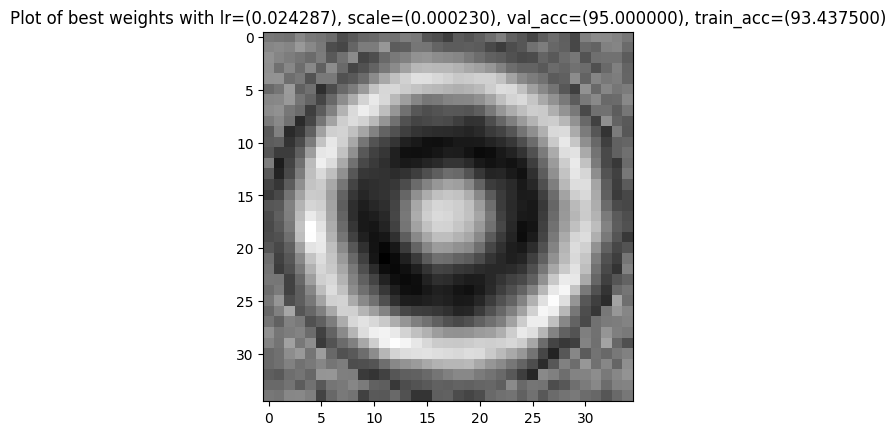

In [117]:
num_epochs_search = 8
num_epochs_total  = 1
ratio_subset = 0.30 # Required because of time constraints

r_i = np.random.choice(labels_train_aug.size, int(labels_train_aug.size * ratio_subset), replace=False)
subset_labels_train_aug = labels_train_aug[r_i] 
subset_examples_train_aug = examples_train_aug[r_i]
subset_labels_train_aug = labels_train_aug[r_i] 
subset_examples_train_aug = examples_train_aug[r_i]

# Fine search on subset
print("\n" + "-" * 20)
print("Processing grid search from subset of augmented values")
learning_rates = np.linspace(best_lr * 0.5, best_lr * 1.5, num=20)
scales = np.linspace(best_scale * 0.5, best_scale * 1.5, num=20)
best_accuracy, best_w, best_w0, best_lr, best_scale = run_grid_search(learning_rates, scales, subset_examples_train_aug, subset_labels_train_aug, examples_val, labels_val, num_epochs_search)

# Full search using candidate hyperparameters
# print("\n" + "-" * 20)
# print("Full search using candidate hyperparameters")
# w, w0 = train(best_w.copy(), best_w0, best_lr, examples_train_aug, labels_train_aug, num_epochs_total, 0)

w = best_w
w0 = best_w0

acc = accuracy(labels_val, classify(examples_val, w, w0))
train_acc = accuracy(labels_train, classify(examples_train, w, w0))
plt.imshow(best_w, cmap='gray')
plt.title(f"Plot of best weights with lr=({best_lr:.6f}), scale=({best_scale:.6f}), val_acc=({acc:.6f}), train_acc=({train_acc:.6f})")
plt.show()

In [118]:
acc = accuracy(labels_val, classify(examples_val, w, w0))
train_acc = accuracy(labels_train, classify(examples_train, w, w0))
print(f"Test Accuracy with augmentation: {acc}, Train accuracy: {train_acc}")

Test Accuracy with augmentation: 95.0, Train accuracy: 93.4375


## Task 3: Convolutional neural networks
In the last part, your task is to train a convolutional neural network to classify handwritten digits from the MNIST dataset using the PyTorch package.



### Task 3.1
Run the following cell to load MNIST, a dataset of images of digits. Plot a few of them to see what the data looks like.

In [14]:
def load_mnist_training_validation(percentage_validation: float, batch_size: int) -> Tuple[DataLoader, DataLoader]:
    """
        Loads the MNIST dataset and splits it into training and validation sets based on the specified percentage for validation.

    Args:
        percentage_validation: The percentage of the training data to be used for validation (e.g., 0.1 for 10% validation)
        batch_size: The batch size to be used for the DataLoaders

    Returns:
        train_loader: DataLoader for the training set
        val_loader: DataLoader for the validation set
    """

    # Define transformations (convert images to tensors and normalize them)
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.1307,), (0.3081,))  # Normalize with mean and std of MNIST
    ])
    
    # Load full training dataset
    full_train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    
    # Define train-validation split (e.g., 90% train, 10% validation)
    percentage_training = 1-percentage_validation
    train_size = int(percentage_training * len(full_train_dataset))  # 90% of the data
    val_size = len(full_train_dataset) - train_size  # Remaining 10% for validation
    print(f"{train_size} images for training  and {val_size} images for validation")
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # Create DataLoaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

def load_mnist_test(batch_size: int = 64) -> DataLoader:
    """
    Loads the MNIST test dataset and returns a DataLoader for it.
    
    Args:
        batch_size: The batch size to be used for the DataLoader

    Returns:
        test_loader: DataLoader for the test set
    """
    # Define transformations (convert images to tensors and normalize them)
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.1307,), (0.3081,))  # Normalize with mean and std of MNIST
    ])

    # Load test dataset
    test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    return test_loader

54000 images for training  and 6000 images for validation
Batch of images: torch.Size([64, 1, 28, 28])
Batch of labels: torch.Size([64])


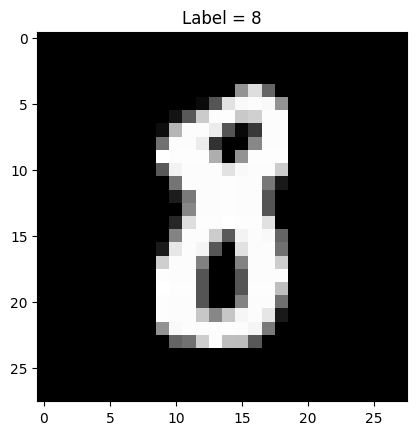

In [19]:
percentage_validation = 0.1 # Define percentage of images to use for validation
batch_size = 64 # Define batch size
train_loader, val_loader = load_mnist_training_validation(percentage_validation,batch_size)

# Example: Iterate through the data loader and get one batch of images and labels
img_idx = 14 # Can try any index between 0 and (batch_size-1) 
for images, labels in train_loader:
    print(f"Batch of images: {images.shape}")
    print(f"Batch of labels: {labels.shape}")
    image = images[img_idx,0,:,:]
    label = labels[img_idx]
    plt.imshow(image,cmap="gray")
    plt.title(f"Label = {label}")
    break  # Just to show one batch

### Task 3.2
The next step is to define a network for classification. You should define a PyTorch model that implements the following network:

![title](./img/simple_cnn.png)

Below is an example of how a simple PyTorch network can be defined. Use the PyTorch tutorials and documentation as a guide.

In [15]:
# Example, not intended to be used.
class simple_feedforward_network(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(simple_feedforward_network, self).__init__()
        # Defining the layers needed for the network
        self.fc1 = nn.Linear(input_size, hidden_size)  # First fully connected layer
        self.relu = nn.ReLU()  # ReLU activation
        self.fc2 = nn.Linear(hidden_size, output_size)  # Output layer
    
    def forward(self, x):
        # Defining the forward pass
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Apart from the layers used in the example above the functions `nn.Conv2d` and `nn.MaxPool2d` will be useful. Note that you have to set the stride for max pooling to 2 to get the expected downsampling. Your network can directly return the output from the final fully connected layer (the raw logits) since we will use the loss function `nn.CrossEntropyLoss` that internally applies the softmax operation to convert this to class probabilities.

You should fill in this template to design the asked for network.

In [16]:
class basic_cnn_classifier(nn.Module):
    def __init__(self):
        super(basic_cnn_classifier, self).__init__()
        # Define the layers needed for your network

        self.conv1 = nn.Conv2d(1, 25, 3) # Output dim is (BATCH, 25, 26, 26)
        self.relu = nn.ReLU()
        self.maxPool = nn.MaxPool2d(2, stride=2) # Output dim is (BATCH, 25, 13, 13)
        self.fc = nn.Linear(4225, 10) # Input dim is (BATCH, 25 * 13 * 13) and output is the 10 numbers

    def forward(self, x):
        # Define the forward pass through the network

        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxPool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


### Task 3.3
You should now train the network using the following training loop defined in `train_model`.

In [20]:
def train_model(
        model: torch.nn.Module, 
        train_loader: torch.utils.data.DataLoader, 
        test_loader: torch.utils.data.DataLoader, 
        num_epochs: int, 
        optimizer: torch.optim.Optimizer, 
        loss_fn: torch.nn.Module, 
        device: torch.device):
    
    """
    Trains the given model using the provided training and test data loaders, optimizer, and loss function for a specified number of epochs.
    
    Args:
        model (torch.nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
        num_epochs (int): Number of epochs to train the model.
        optimizer (torch.optim.Optimizer): The optimizer to use for training (e.g., Adam, SGD).
        loss_fn (torch.nn.Module): The loss function to use for training (e.g., CrossEntropyLoss).
        device (torch.device): The device to run the training on (e.g., 'cuda' or 'cpu').
    
    Returns:
        (torch.nn.Module): The trained model after the specified number of epochs.
    """
    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            # Move data to the correct device (GPU or CPU)
            inputs, targets = inputs.to(device), targets.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute the loss
            loss = loss_fn(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

        # Print the training statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

        # Validation loop (optional, to check model performance on validation data)
        model.eval()  # Set the model to evaluation mode
        val_correct = 0
        val_total = 0
        with torch.no_grad():  # Disable gradient calculation for validation
            for inputs, targets in tqdm(test_loader, desc="Validation", leave=False):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                val_total += targets.size(0)
                val_correct += (predicted == targets).sum().item()

        val_acc = 100 * val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.2f}%")

    print("Training complete.")
    return model

In [21]:
# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training loop
num_epochs = 5
lr = 0.001

# Initialize model, loss function, and optimizer
basic_model = basic_cnn_classifier().to(device)
loss_fn = nn.CrossEntropyLoss()  # Define the loss function

optimizer = optim.SGD(basic_model.parameters(), lr=lr)

basic_model_trained = train_model(basic_model, train_loader, val_loader, num_epochs, optimizer,loss_fn,device)

Using device: cuda


Training:   0%|                                           | 0/5 [00:00<?, ?it/s]

Epoch [1/5], Loss: 0.7310, Accuracy: 83.03%



Training:  20%|███████                            | 1/5 [00:05<00:21,  5.37s/it]

Validation Accuracy: 88.22%
Epoch [2/5], Loss: 0.3892, Accuracy: 89.43%


...

Validation Accuracy: 90.90%
Epoch [4/5], Loss: 0.3108, Accuracy: 91.24%



Training:  80%|████████████████████████████       | 4/5 [00:19<00:04,  4.85s/it]

Validation Accuracy: 91.43%
Epoch [5/5], Loss: 0.2930, Accuracy: 91.74%



Training: 100%|███████████████████████████████████| 5/5 [00:24<00:00,  4.92s/it]

Validation Accuracy: 91.62%
Training complete.


### Task 3.4
Work out how many trainable parameters your network contains. Note that the convolution layer does not use padding so the output from the convolution layer is smaller than the input.

**Your answer:**

The number of trainable parameters is:

**Conv2d:**

Given $K$ as kernel size, $C_{\text{out}}$ as number of output channels (or filters), and $C_{\text{in}}$ as number of input channels we can calculate:

\begin{align}
P_1 & = (K^2 * C_{\text{in}} + 1) * C_{\text{out}} \\
P_1 & = (3^2 * 1 + 1) * 25 \\
P_1 & = 250 \\
\end{align}

where:

$$
K = 3, \quad C_{\text{out}} = 25, \quad C_{\text{in}} = 1
$$

from the specification in the diagram. The dimension of the images is reduced according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{1} + 1 \\
D_{\text{out}} &= \frac{28 + 2 * 0 - (3 - 1) - 1}{1} + 1 \\
D_{\text{out}} &= 25 + 1 \\
D_{\text{out}} &= 26 \\
\end{align}

Note that the images are square and we only show the calculation for one dimension. The other dimension is identically computed and the same applies to the calculations below.

The number of channels is now $C_{\text{out}} = 25$ giving a shape of (Batch, 25, 26, 26)

**ReLU:**

ReLU does not have trainable parameters and does not change the output dimension or the number of channels.

**MaxPool2d:**

MaxPool2d does not have trainable parameters but it does change the output dimension according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{2} + 1 \\
D_{\text{out}} &= \frac{26 + 2 * 0 - (2 - 1) - 1}{2} + 1 \\
D_{\text{out}} &= (24 / 2) + 1 \\
D_{\text{out}} &= 13 \\
\end{align}

However, the number of channels is preserved which gives a shape of (Batch, 25, 13, 13).

**Linear:**

Following the above transformations, we have that the input dimension of the images to the linear layer is $D_{\text{in}} = 13$. Therefore, flattening the images into vectors for the linear layer gives $F_{\text{in}} = C_{\text{out}} * D_{\text{in}} * D_{\text{in}} = 25 * 13 * 13 = 4225$. Then we can compute:

\begin{align}
P_1 & = (F_{\text{in}} * D_{\text{out}}) + D_{\text{out}} \\
P_1 & = (4225 * 10) + 10 \\
P_1 & = 42260 \\
\end{align}

**Result:**

The total number of trainable parameters is then $P_1 + P_2 = 250 + 42260 = 42510$

### Task 3.5
To run a convolutional neural network we have to perform a massive amount of computations. Hence it is very important to consider the computational load when designing a network. For the network below, compare (roughly) the time consumption (number of computations required) for the blue and the red layers. You can ignore effects of padding. NOTE: You are not supposed to actually implement and train this network.


![title](img/blue_red_cnn.PNG)

**Your answer:** 

In order to determine the number of computations required we must first determine the input dimensions to both the the blue and the red layer. We follow a similar process as above when calculating the dimensions. Assuming the same variable declarations as before for simplicity we can calculate the dimensional reduction for each layer as:

**10 Conv 5x5 (1):**
With:

$$
K = 5, \quad C_{\text{out}} = 10, \quad C_{\text{in}} = 1
$$

from the specification in the diagram. The dimension of the images is reduced according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{1} + 1 \\
D_{\text{out}} &= \frac{28 + 2 * 0 - (5 - 1) - 1}{1} + 1 \\
D_{\text{out}} &= 23 + 1 \\
D_{\text{out}} &= 24 \\
\end{align}

Note that the images are square and we only show the calculation for one dimension. The other dimension is identically computed and the same applies to the calculations below.

The number of channels is now $C_{\text{out}} = 10$ giving a shape of (Batch, 10, 24, 24)

**ReLU (1):**

ReLU does not have trainable parameters and does not change the output dimension or the number of channels.

**10 Conv 5x5 (2 / BLUE LAYER):**

With:

$$
K = 5, \quad C_{\text{out}} = 10, \quad C_{\text{in}} = 10
$$

from the specification in the diagram. The dimension of the images is reduced according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{1} + 1 \\
D_{\text{out}} &= \frac{24 + 2 * 0 - (5 - 1) - 1}{1} + 1 \\
D_{\text{out}} &= 19 + 1 \\
D_{\text{out}} &= 20 \\
\end{align}

The number of channels is now $C_{\text{out}} = 10$ giving a shape of (Batch, 10, 20, 20)

**ReLU (2):**

ReLU does not have trainable parameters and does not change the output dimension or the number of channels.

**MaxPool (1):**

MaxPool does not have trainable parameters but it does change the output dimension according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{2} + 1 \\
D_{\text{out}} &= \frac{20 + 2 * 0 - (2 - 1) - 1}{2} + 1 \\
D_{\text{out}} &= (18 / 2) + 1 \\
D_{\text{out}} &= 10 \\
\end{align}

However, the number of channels is preserved which gives a shape of (Batch, 10, 10, 10).

**10 Conv 5x5 (3):**

With:

$$
K = 5, \quad C_{\text{out}} = 10, \quad C_{\text{in}} = 10
$$

from the specification in the diagram. The dimension of the images is reduced according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{1} + 1 \\
D_{\text{out}} &= \frac{10 + 2 * 0 - (5 - 1) - 1}{1} + 1 \\
D_{\text{out}} &= 5 + 1 \\
D_{\text{out}} &= 6 \\
\end{align}

The number of channels is now $C_{\text{out}} = 10$ giving a shape of (Batch, 10, 6, 6)

**ReLU (3):**

ReLU does not have trainable parameters and does not change the output dimension or the number of channels.

**MaxPool (2):**

MaxPool does not have trainable parameters but it does change the output dimension according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{2} + 1 \\
D_{\text{out}} &= \frac{6 + 2 * 0 - (2 - 1) - 1}{2} + 1 \\
D_{\text{out}} &= (4 / 2) + 1 \\
D_{\text{out}} &= 3 \\
\end{align}

However, the number of channels is preserved which gives a shape of (Batch, 10, 3, 3).

**20 Conv 5x5 (1 / RED LAYER):**

With:

$$
K = 5, \quad C_{\text{out}} = 20, \quad C_{\text{in}} = 10
$$

from the specification in the diagram. The dimension of the images is reduced according to:

\begin{align}
D_{\text{out}} &= \frac{D_{\text{in}} + 2 * \text{padding} - (K - 1) - 1}{1} + 1 \\
D_{\text{out}} &= \frac{3 + 2 * 0 - (5 - 1) - 1}{1} + 1 \\
D_{\text{out}} &= -2 + 1 \\
D_{\text{out}} &= -1 \\
\end{align}

The number of channels is now $C_{\text{out}} = 20$ giving a shape of (Batch, 20, -1, -1)

**ReLU (3):**

ReLU does not have trainable parameters and does not change the output dimension or the number of channels.

**Result:**

We can compute the number of computations required as the number of floating point operations (FLOPs) needed when performing inference on the model. We can define this in terms of a multiply-accumulate (MAC) operation, which is an operation where one multiplication between two scalars occurs and the result is added by one addition operation to a running sum. This means that each MAC operation is equivalent to 2 FLOPs. 

An example of a MAC in the convolutional layer is the dot product between the filter and the patch of the image corresponding to one output pixel. Since it is a matrix dot product we get $K^2$ MACs which spread across $C_{\text{in}}$ input channels produces $C_{\text{in}} * K^2$ MACs. As stated above, one MAC is two FLOPs so we can double the equation and add the bias term addition to each convolution which results in $2 * C_{\text{in}} * K^2 + 1$. Consequently, we have arrived at the number of FLOPs required to calculate a single output pixel from a single patch of the input. The number of pixels we need to calculate for the output is $C_{\text{out}} * D_{\text{out}}^2$ meaning we have a grand total of $C_{\text{out}} * D_{\text{out}}^2 * (2 * C_{\text{in}} * K^2 + 1)$ FLOPs for one convolutional layer.

We can now apply the above equation to the blue layer:

$$
C_{\text{out}} * D_{\text{out}}^2 * (2 * C_{\text{in}} * K^2 + 1) = 10 * 20^2 * (2 * 10 * 5^2 +1) = 4000 * 501 = 2{,}004{,}000 \space \text{FLOPs}
$$

Unfortunately, it is not possible to calculate the number of FLOPs for the red layer. As shown in the dimensionality reduction calculations, once we reach the red layer the spatial dimensions have been reduced to $-1 \times -1$, which is geometrically impossible. A 5×5 kernel cannot be applied to a 3×3 feature map without padding. We therefore redo the calculation under the intended simplifying assumption below.

---

**Result (ignoring dimensional reduction in convolutional layers):**

As clarified in the task description, we are instructed to ignore the effects that convolutional layers have on spatial dimensions and focus on other factors. We therefore treat the spatial dimensions as unchanged by convolutions, and only apply dimensional reduction from the MaxPool layers. Under this assumption the dimensions reduce as:

| Layer | Spatial dim |
|---|---|
| Input | 28×28 |
| Conv 5×5 (1) | 28×28 |
| ReLU (1) | 28×28 |
| Conv 5×5 Blue | 28×28 |
| ReLU (2) | 28×28 |
| MaxPool 2×2 (1) | 14×14 |
| Conv 5×5 (3) | 14×14 |
| ReLU (3) | 14×14 |
| MaxPool 2×2 (2) | 7×7 |
| Conv 5×5 Red | 7×7 |

The blue layer therefore receives a $28 \times 28$ feature map and the red layer receives a $7 \times 7$ feature map. Applying the same FLOPs formula as above:

$$
\text{Blue:} \quad 10 * 28^2 * (2 * 10 * 5^2 + 1) = 7840 * 501 = 3{,}927{,}840 \space \text{FLOPs}
$$

$$
\text{Red:} \quad 20 * 7^2 * (2 * 10 * 5^2 + 1) = 980 * 501 = 490{,}980 \space \text{FLOPs}
$$

The ratio is:

$$
\frac{\text{Blue}}{\text{Red}} = \frac{3{,}927{,}840}{490{,}980} \approx 8
$$

The blue layer therefore requires roughly 8 times more computation than the red layer. Despite the red layer having twice as many output channels, the two max-pooling operations before it reduce the spatial dimensions from $28 \times 28$ to $7 \times 7$ which is a factor of 16 reduction in the number of output pixels. This effect far outweighs the doubling of $C_{\text{out}}$.

### Task 3.6

Imagine that the blue box of the network in the figure above is replaced by a sequence of two layers of 10 3 × 3 convolutional filters. What changes in terms of network parameters, time consumption (number of computations) and accuracy would that lead to?


**Your answer:** 

We can begin by calculating the number of computations necessary for the sequence of two layers. Assuming again that the dimensionality reduction does not exist, we calculate:

$$
\text{Layer 1:} \quad 10 * 28^2 * (2 * 10 * 3^2 + 1) = 7840 * 181 = 1{,}419{,}040 \space \text{FLOPs}
$$

$$
\text{Layer 2:} \quad 10 * 28^2 * (2 * 10 * 3^2 + 1) = 7840 * 181 = 1{,}419{,}040 \space \text{FLOPs}
$$

Observe that the total amount of FLOPs is less than for the single blue layer. In fact the number of FLOPs is reduced by $1{,}089{,}760$.

We can also calculate the number of parameters for the blue layer and compare with the sequence layers:

$$
\text{Blue:} \quad (K^2 * C_{\text{in}} + 1) * C_{\text{out}} = (5^2 * 10 + 1) * 10 = 251 * 10 = 2510
$$

$$
\text{Sequence Layers:} \quad 2 * (K^2 * C_{\text{in}} + 1) * C_{\text{out}} = 2 * (3^2 * 10 + 1) * 10 = 2 * 91 * 10 = 1820
$$

Observe that the number of trainable parameters has also been reduced by replacing the blue layer with a sequence of layers with a smaller kernel. As a result, we can draw the conclusion that both training and inference will be faster on the model with the sequence of layers as opposed to the single blue layer. Less computation time for forward passes due to a reduction in the number of FLOPs and faster on the backward pass (weight updates) due to less parameters being updated. However, if this change increases the accuracy of the model is arguably difficult to determine.

Decreasing the number of parameters reduces the complexity of the model since there are less parameters available to learn the data distribution. Considering that the task we wish our model to complete can vary in its complexity, reducing the number of parameters may make it more difficult to learn complex patterns in the data. Nevertheless, the sequence version increases the depth of the model which can actually improve accuracy by iterative refinement as opposed to one large layer. By allowing the data to flow through a few smaller layers we increase the number of filters passing over the data. As a result, we increase the potential variability in what each filter can look at on the data it observes. This can increase the models ability to detect features that otherwise would not have been seen at a coarser granularity in the single blue layer.aveat 

There is one caveat to the above discussion, it requires a non-linear activation function between the two sequence layers. If this does not exist, then the potential benefits to accuracy don't apply. This is because two linear operations applied directly after eachother is mathematically equivalent to performing one larger linear operation. Therefore, without a non-linear activation function, splitting the blue layer into two sequenced layers only reduces the time consumption and complexity, but does not offer additional benefits in learning complex features by iterative refinement.

In summary, it is difficult to definitively claim that the accuracy increases or decreases as a result of the change since it depends heavily on the distribution of the data, the task we aim to complete, and if we consider a non-linear activation function between the sequence layers or not. However, we can with certainty say the model will be both faster to train and faster on inference.

### Task 3.7
Make a copy of `basic_cnn_classifier` and name it `better_cnn_classifier`. Try modifying the network by adding more layers. Also experiment with the training options. How much can you improve the results?

In [90]:
class better_cnn_classifier(nn.Module):
    def __init__(self):
        super(better_cnn_classifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 40, 5) # Output dim is (BATCH, 40, 24, 24)
        self.relu1 = nn.ReLU()
        self.maxPool1 = nn.MaxPool2d(2, stride=2) # Output dim is (BATCH, 40, 12, 12)
        self.conv2 = nn.Conv2d(40, 40, 5) # Output dim is (BATCH, 40, 8, 8)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(40, 40, 3) # Output dim is (BATCH, 40, 6, 6)
        self.relu3 = nn.ReLU()
        # self.maxPool2 = nn.MaxPool2d(2, stride=2) # Output dim is (BATCH, 40, 3, 3)
        self.fc1 = nn.Linear(1440, 360) # Input dim is (BATCH, 40 * 6 * 6)
        self.fc2 = nn.Linear(360, 10) # Input dim is (BATCH, 40 * 3 * 3) and output is the 10 numbers

    def forward(self, x):
        # Define the forward pass through the network
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxPool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        # x = self.maxPool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [91]:
# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training loop
num_epochs = 30
lr = 0.005

# Initialize model, loss function, and optimizer
better_model = better_cnn_classifier().to(device)
loss_fn = nn.CrossEntropyLoss()  # Define the loss function
optimizer = optim.SGD(better_model.parameters(), lr=lr)

better_model_trained = train_model(better_model, train_loader, val_loader, num_epochs, optimizer,loss_fn,device)

Using device: cuda


Training:   0%|                                          | 0/30 [00:00<?, ?it/s]

Epoch [1/30], Loss: 0.7880, Accuracy: 78.29%



Training:   3%|█▏                                | 1/30 [00:06<02:57,  6.11s/it]

Validation Accuracy: 89.65%
Epoch [2/30], Loss: 0.2459, Accuracy: 92.74%


...

Validation Accuracy: 99.05%
Epoch [29/30], Loss: 0.0261, Accuracy: 99.21%



Training:  97%|███████████████████████████████▉ | 29/30 [03:03<00:06,  6.35s/it]

Validation Accuracy: 98.92%
Epoch [30/30], Loss: 0.0260, Accuracy: 99.21%



Training: 100%|█████████████████████████████████| 30/30 [03:09<00:00,  6.32s/it]

Validation Accuracy: 99.00%
Training complete.


### Task 3.8
You should now take your model that gave best results on the validation set and evaluate it on the test set. Compute precision and recall for each of the 10 classes. 

In [92]:
def precision(labels: np.ndarray, predicted_labels: np.ndarray) -> float:
    """
    Computes the precision of the classifier.
    
    Args:
        labels: true labels (shape (N,))
        predicted_labels: predicted labels (shape (N,))
    
    Returns:
        precision: Precision of the classifier as a percentage
    """
    target_c = labels[0]
    
    TP = np.sum((predicted_labels == target_c) & (labels == target_c))
    FP = np.sum((predicted_labels == target_c) & (labels != target_c))

    return (TP / (TP + FP))*100

def recall(labels: np.ndarray, predicted_labels: np.ndarray) -> float:
    """
    Computes the recall of the classifier.
    
    Args:
        labels: true labels (shape (N,))
        predicted_labels: predicted labels (shape (N,))
    
    Returns:
        recall: Recall of the classifier as a percentage
    """
    target_c = labels[0]
    
    TP = np.sum((predicted_labels == target_c) & (labels == target_c))
    FN = np.sum((predicted_labels != target_c) & (labels == target_c))

    return (TP / (TP + FN))*100

def metrics_on_test_set(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, device: torch.device) -> Dict[int, Dict[str, float]]:
    """
    Evaluates the model on the test set and computes precision and recall.
    
    Args:
        model (torch.nn.Module): The trained model to be evaluated.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
        device (torch.device): The device to run the evaluation on (e.g., 'cuda' or 'cpu').
    Returns:
        metrics: A dictionary containing precision and recall for each class with structure {class_label: {'precision': value, 'recall': value}}
    """
    true_labels = []
    predicted_labels = []

    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        true_labels.append(targets)
        predicted_labels.append(predicted)

    true_labels = torch.cat(true_labels).cpu().numpy()
    predicted_labels = torch.cat(predicted_labels).cpu().numpy()
        
    metrics = {}
    for c in range(10):
        indices = true_labels == c
        metrics[c] = {
            'precision': precision(true_labels[indices], predicted_labels[indices]),
            'recall': recall(true_labels[indices], predicted_labels[indices]),
        }

    return metrics


In [93]:
test_loader = load_mnist_test(batch_size=64)

# Evaluate the better model on the test set
test_metrics = metrics_on_test_set(better_model_trained, test_loader, device)
print("Test Metrics (Precision and Recall for each class):")
for cls, metric in test_metrics.items():
    print(f"Class {cls}: Precision = {metric['precision']:.2f}%, Recall = {metric['recall']:.2f}%")

Test Metrics (Precision and Recall for each class):
Class 0: Precision = 100.00%, Recall = 99.18%
Class 1: Precision = 100.00%, Recall = 99.74%
Class 2: Precision = 100.00%, Recall = 99.03%
Class 3: Precision = 100.00%, Recall = 99.11%
Class 4: Precision = 100.00%, Recall = 99.39%
Class 5: Precision = 100.00%, Recall = 98.99%
Class 6: Precision = 100.00%, Recall = 98.33%
Class 7: Precision = 100.00%, Recall = 99.42%
Class 8: Precision = 100.00%, Recall = 98.77%
Class 9: Precision = 100.00%, Recall = 98.91%


### Task 3.9
Plot three images where your model fails with names indicating what digit they were mistaken for and what is the true class. Have a look at the images before submitting it, so it looks right.

Number of incorrect predictions: 90
Number of images total: 10000
Failure rate: 0.009


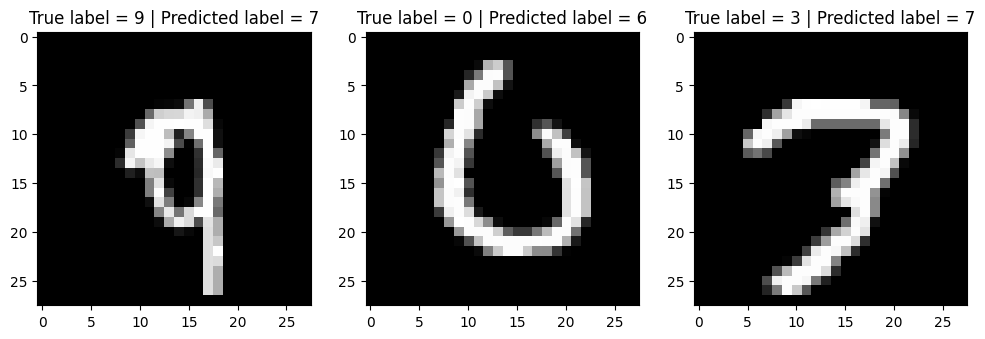

In [94]:
true_labels = []
predicted_labels = []
input_images = []

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = better_model_trained(inputs)
    _, predicted = torch.max(outputs, 1)

    input_images.append(inputs)
    true_labels.append(targets)
    predicted_labels.append(predicted)

true_labels = torch.cat(true_labels).cpu().numpy()
predicted_labels = torch.cat(predicted_labels).cpu().numpy()
input_images = torch.cat(input_images).cpu().numpy()

mask_incorrect_prediction = true_labels != predicted_labels
num_wrong = np.sum(mask_incorrect_prediction)
start_value = np.random.choice(num_wrong-3, 1)[0]
print(f"Number of incorrect predictions: {num_wrong}")
print(f"Number of images total: {input_images.shape[0]}")
print(f"Failure rate: {num_wrong / input_images.shape[0]}")
failed_images = input_images[mask_incorrect_prediction][start_value:]
failed_images_true_labels = true_labels[mask_incorrect_prediction][start_value:]
failed_images_predicted_labels = predicted_labels[mask_incorrect_prediction][start_value:]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    ax = axes[i]
    ax.imshow(failed_images[i,0,:,:], cmap="gray")
    ax.set_title(f"True label = {failed_images_true_labels[i]} | Predicted label = {failed_images_predicted_labels[i]}")